# HealthConnect Clinic: No-Show Prediction
### Week 7 — Model Testing, Error Analysis & Refinement
### AnalystLab Africa Experience Lab, Data Science Track

Week 6 left me with a refined logistic regression model that beat the Week 5 baseline under cross-validation, plus a handful of open questions I didn't have time to chase down: was the new lead-time feature actually pulling its weight, was the model overfitting anywhere, did it behave consistently across different types of patients, and what would happen if I picked a different decision threshold instead of the default 0.5.

This week is about answering those questions properly instead of assuming the answers. Nothing here is a rebuild — it's the Week 6 model, tested.

## 1. Coming in from Week 6

**What I had at the end of last week:** a logistic regression model with a refined feature set (lead-time bands instead of the old short/long flags, plus two interaction features built from the Data Analytics track's crosstabs) that beat the Week 5 baseline on 5-fold cross-validation — accuracy 0.629 vs 0.624, ROC-AUC 0.680 vs 0.680.

**The result that mattered most:** the improvement only showed up once I moved to cross-validation. On the original single train/test split the two models looked basically identical. That was the whole point of switching validation methods, so it's good it actually worked.

**The loose thread from last week:** I added `lead_time_bin` because error analysis showed the old binary flags were missing risk in the 15-30 day range. But I never actually checked whether the *binned* version was better than just leaving `booking_lead_days` as a plain number — I built it because the pattern looked cleaner in bands, not because I'd tested the alternative. That's the first thing this week's notebook resolves.

**Also relevant:** the ML Engineering track needs a finalised feature list and preprocessing steps before they can wire this into the pipeline, so part of this week is making sure what I hand them is actually settled rather than still in flux.

**What Week 7 tests:** whether the lead-time feature genuinely earns its place, whether the model is overfitting, whether it performs evenly across different patient segments, and whether the default 0.5 threshold is even the right call for how HealthConnect would actually use this.

## 2. Part 1 — What I'm Testing and Why

**Component being tested:** the Week 6 refined logistic regression model (the one built on the interaction and lead-time-band features).

**Intended purpose:** flag appointments at elevated no-show risk early enough that HealthConnect can do something about it — an extra reminder, a follow-up call, whatever the clinic's actual intervention ends up being.

**Requirement it needs to satisfy:** it should generalise (not just fit the training data), it should hold up across different kinds of patients rather than only working well for one group, and its features should each be earning their keep rather than sitting there out of habit.

**Tracks connected to this:** Data Analytics (their crosstab findings are baked into two of the features being tested here) and ML Engineering (waiting on the finalised feature list downstream).

**What I'm trying to determine:**
- Does `lead_time_bin` actually beat the plain `booking_lead_days` number it was built from, or was that a Week 6 assumption I never checked?
- Is there a meaningful gap between training and test performance (a sign of overfitting)?
- Does accuracy hold up across appointment types, genders, and age groups, or is the model quietly better for some patients than others?
- Is 0.5 actually the right threshold, or does the intended use case call for something else?

## 3. Testing the Lead-Time Feature

This is the direct question my Data Analytics partner asked me after Week 6: does the binned lead-time feature actually improve the model compared to the simpler version, or was I engineering complexity I didn't need?

Fair question. I hadn't tested it head to head, I'd just replaced the old flags with bins because the crosstab pattern looked cleaner that way. Here's the actual comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')
df['reminder_channel'] = df['reminder_channel'].fillna('None')
df['no_show_rate_history'] = np.where(df['previous_appointments'] > 0, df['previous_no_shows'] / df['previous_appointments'], 0)
df['is_first_appointment'] = (df['previous_appointments'] == 0).astype(int)
df['is_weekend_appt'] = df['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)
df['reminder_sent_bin'] = (df['reminder_sent'] == 'Yes').astype(int)
df['prevnoshow_x_reminder'] = df['previous_no_shows'] * (1 - df['reminder_sent_bin'])
df['high_risk_no_reminder'] = ((df['previous_no_shows'] >= 1) & (df['reminder_sent'] == 'No')).astype(int)
df['distance_x_no_reminder'] = df['distance_to_clinic_km'] * (1 - df['reminder_sent_bin'])
df['lead_time_bin'] = pd.cut(df['booking_lead_days'], bins=[-1, 15, 30, 45, 1000], labels=['0-15', '15-30', '30-45', '45+'])

y = df['is_no_show']
groups = df['patient_id']
gkf = GroupKFold(n_splits=5)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

shared_numeric = ['age', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km',
                   'distance_missing_flag', 'no_show_rate_history', 'is_first_appointment',
                   'is_weekend_appt', 'prevnoshow_x_reminder', 'high_risk_no_reminder', 'distance_x_no_reminder']
shared_categorical = ['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']

def run_cv(numeric_feats, categorical_feats, label):
    X = df[numeric_feats + categorical_feats]
    prep = ColumnTransformer([('num', 'passthrough', numeric_feats), ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_feats)])
    pipe = Pipeline([('prep', prep), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))])
    cv = cross_validate(pipe, X, y, groups=groups, cv=gkf, scoring=scoring, n_jobs=1)
    return {'version': label, **{m: cv[f'test_{m}'].mean() for m in scoring}, **{f'{m}_std': cv[f'test_{m}'].std() for m in scoring}}

results = []
results.append(run_cv(shared_numeric + ['booking_lead_days'], shared_categorical, 'Raw booking_lead_days only'))
results.append(run_cv(shared_numeric + ['booking_lead_days'], shared_categorical + ['lead_time_bin'], 'Raw + lead_time_bin (Week 6 version)'))
results.append(run_cv(shared_numeric, shared_categorical + ['lead_time_bin'], 'lead_time_bin only (no raw days)'))

pd.DataFrame(results).set_index('version')[['accuracy', 'roc_auc']].round(4)

,accuracy,roc_auc
version,,
Raw booking_lead_days only,0.6276,0.6803
Raw + lead_time_bin (Week 6 version),0.6274,0.6802
lead_time_bin only (no raw days),0.6244,0.6782


Honestly, the answer is no. The Week 6 version (raw days plus the bins) comes in essentially tied with plain `booking_lead_days` on its own — a couple of hundredths of a point apart on both accuracy and ROC-AUC, nowhere near enough to call a real difference. And when I stripped the raw number out and left only the bins, performance actually came in a bit lower than either of the other two versions.

What's going on here is that the raw `booking_lead_days` number was already doing most of the work. Logistic regression doesn't need a lot of help finding a roughly monotonic relationship like "longer lead time, higher risk" — it can pick that up from the continuous number on its own. The binning made the pattern more *visible* in a crosstab, which is genuinely useful for a business audience reading a report, but it wasn't adding new information the model didn't already have.

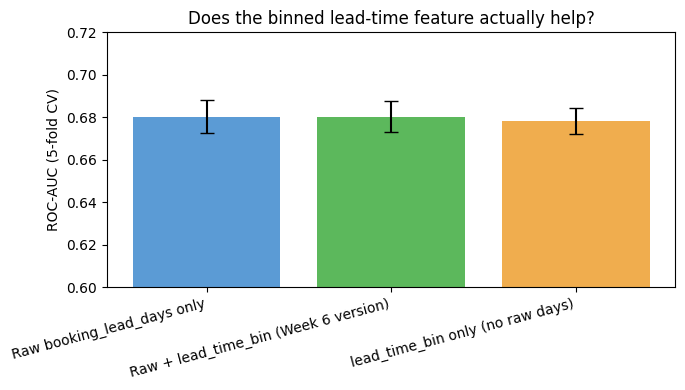

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
res_df = pd.DataFrame(results).set_index('version')
x = np.arange(len(res_df))
ax.bar(x, res_df['roc_auc'], yerr=res_df['roc_auc_std'], capsize=5, color=['#5b9bd5', '#5cb85c', '#f0ad4e'])
ax.set_xticks(x)
ax.set_xticklabels(res_df.index, rotation=15, ha='right')
ax.set_ylabel('ROC-AUC (5-fold CV)')
ax.set_ylim(0.6, 0.72)
ax.set_title('Does the binned lead-time feature actually help?')
plt.tight_layout()
plt.savefig('processed_w7/fig1_leadtime_ablation.png', dpi=100)
plt.show()

**So what do I do with that?** I'm keeping `lead_time_bin` in the feature set anyway, but not because it lifts accuracy — because it makes the model's reasoning easier to explain to someone at HealthConnect who isn't going to read a logistic regression coefficient table. "Risk climbs the further out someone books, especially past 45 days" is a sentence a clinic manager can act on. A single coefficient on a continuous day-count isn't. That's a legitimate reason to keep a feature even when it's not moving the accuracy needle, but it's a different reason than the one I had in my head last week, and it's worth being honest about that distinction rather than pretending the feature was a performance win it wasn't.

This is also a good example of something Week 6 got a little ahead of itself on: I validated that the Data Analytics *crosstab pattern* was real, but I hadn't yet validated that turning it into a categorical feature was the best way to use it. Those are two different questions.

## 4. Overfitting Check

Before trusting any of the segment or threshold testing below, I wanted to rule out the model just memorising the training set.

In [3]:
numeric_v2 = shared_numeric + ['booking_lead_days']
categorical_v2 = shared_categorical + ['lead_time_bin']
X_v2 = df[numeric_v2 + categorical_v2]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_v2, y, groups))

preprocessor = ColumnTransformer([('num', 'passthrough', numeric_v2), ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_v2)])
model = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))])
model.fit(X_v2.iloc[train_idx], y.iloc[train_idx])

train_pred = model.predict(X_v2.iloc[train_idx])
train_proba = model.predict_proba(X_v2.iloc[train_idx])[:, 1]
test_pred = model.predict(X_v2.iloc[test_idx])
test_proba = model.predict_proba(X_v2.iloc[test_idx])[:, 1]

print(f"Train accuracy: {accuracy_score(y.iloc[train_idx], train_pred):.4f}   Train ROC-AUC: {roc_auc_score(y.iloc[train_idx], train_proba):.4f}")
print(f"Test accuracy:  {accuracy_score(y.iloc[test_idx], test_pred):.4f}   Test ROC-AUC:  {roc_auc_score(y.iloc[test_idx], test_proba):.4f}")
print(f"Gap:            {accuracy_score(y.iloc[train_idx], train_pred) - accuracy_score(y.iloc[test_idx], test_pred):+.4f} accuracy, "
      f"{roc_auc_score(y.iloc[train_idx], train_proba) - roc_auc_score(y.iloc[test_idx], test_proba):+.4f} ROC-AUC")

Train accuracy: 0.6380   Train ROC-AUC: 0.6918
Test accuracy:  0.6346   Test ROC-AUC:  0.6789
Gap:            +0.0035 accuracy, +0.0129 ROC-AUC


Gap's tiny — about a third of a point of accuracy, just over a point of ROC-AUC. That's not overfitting, that's just a model that performs about the same on data it hasn't seen as on data it has, which is what you want. Logistic regression with this few features on a dataset this size was never a huge overfitting risk to begin with, but it's still worth checking rather than assuming.

## 5. Does It Perform Evenly Across Patient Segments?

Aggregate accuracy can hide a model that's great for one group and mediocre for another. Worth a look before calling this done.

In [4]:
test_df = df.iloc[test_idx].copy()
test_df['pred'] = test_pred
test_df['proba'] = test_proba
test_df['actual'] = y.iloc[test_idx].values

for seg_col in ['appointment_type', 'gender', 'age_group']:
    print(f"--- Accuracy by {seg_col} ---")
    for seg, grp in test_df.groupby(seg_col):
        print(f"  {seg}: n={len(grp)}, accuracy={accuracy_score(grp['actual'], grp['pred']):.4f}")
    print()

--- Accuracy by appointment_type ---
  Diagnostic Test: n=109, accuracy=0.7156
  Follow-up: n=271, accuracy=0.6421
  General Consultation: n=406, accuracy=0.6305
  Specialist Consultation: n=180, accuracy=0.5833

--- Accuracy by gender ---
  Female: n=461, accuracy=0.6464
  Male: n=479, accuracy=0.6221
  Prefer not to say: n=26, accuracy=0.6538

--- Accuracy by age_group ---
  18-24: n=117, accuracy=0.6325
  25-34: n=143, accuracy=0.6503
  35-44: n=165, accuracy=0.6424
  45-54: n=163, accuracy=0.6380
  55-64: n=138, accuracy=0.6812
  65+: n=240, accuracy=0.5917



There's a real spread here. `Specialist Consultation` sits at 58.3% accuracy versus `Diagnostic Test` at 71.6% — a 13-point gap. Age tells a similar story: the 65+ group is the weakest segment at 59.2%, while 55-64 is the strongest at 68.1%.

I don't think this means the model is broken for specialist appointments or older patients — the sample sizes per segment are on the small side (109 for Diagnostic Test, 240 for 65+), so some of this spread is just noise from a modest test set. But it's not nothing either, and it's the kind of thing that should get flagged rather than buried. If HealthConnect ends up using this for outreach decisions, they should know the model is less reliable for specialist appointments and for older patients specifically, and treat predictions in those segments with a bit more caution until there's more data to check whether the gap holds up.

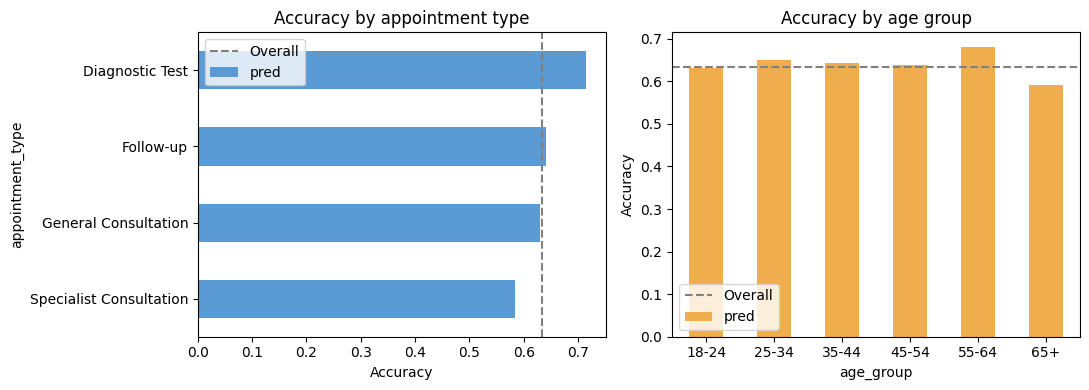

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

seg_acc = test_df.groupby('appointment_type')['pred'].apply(lambda p: accuracy_score(test_df.loc[p.index, 'actual'], p))
seg_acc.sort_values().plot(kind='barh', ax=axes[0], color='#5b9bd5')
axes[0].axvline(accuracy_score(test_df['actual'], test_df['pred']), color='grey', linestyle='--', label='Overall')
axes[0].set_title('Accuracy by appointment type')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

age_acc = test_df.groupby('age_group')['pred'].apply(lambda p: accuracy_score(test_df.loc[p.index, 'actual'], p))
age_acc.sort_index().plot(kind='bar', ax=axes[1], color='#f0ad4e')
axes[1].axhline(accuracy_score(test_df['actual'], test_df['pred']), color='grey', linestyle='--', label='Overall')
axes[1].set_title('Accuracy by age group')
axes[1].set_ylabel('Accuracy')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.savefig('processed_w7/fig2_segment_performance.png', dpi=100)
plt.show()

## 6. Threshold Testing

Everything so far has used the default 0.5 cutoff without ever asking whether that's actually the right call for how HealthConnect would use this. If the intervention is something cheap — an extra reminder call, say — then missing a real no-show (a false negative) probably costs more than a wasted reminder (a false positive). That argues for a lower threshold that trades some precision for recall.

In [6]:
thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65]
rows = []
for t in thresholds:
    pred_t = (test_proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'accuracy': accuracy_score(y.iloc[test_idx], pred_t),
        'precision': precision_score(y.iloc[test_idx], pred_t, zero_division=0),
        'recall': recall_score(y.iloc[test_idx], pred_t, zero_division=0),
    })
threshold_df = pd.DataFrame(rows).set_index('threshold')
threshold_df.round(4)

,accuracy,precision,recall
threshold,,,
0.40,0.6201,0.5881,0.8012
0.45,0.6325,0.6131,0.7184
0.50,0.6346,0.6371,0.6253
0.55,0.6232,0.6545,0.5217
0.60,0.6025,0.6656,0.4120
0.65,0.5890,0.7087,0.3023


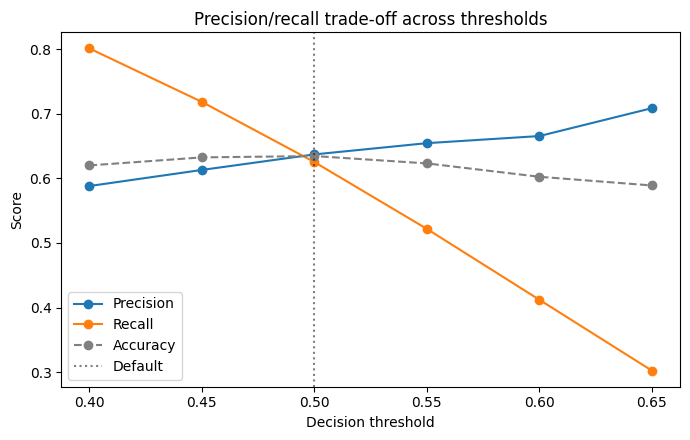

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(threshold_df.index, threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df.index, threshold_df['recall'], marker='o', label='Recall')
ax.plot(threshold_df.index, threshold_df['accuracy'], marker='o', label='Accuracy', linestyle='--', color='grey')
ax.axvline(0.5, color='black', linestyle=':', alpha=0.5, label='Default')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision/recall trade-off across thresholds')
ax.legend()
plt.tight_layout()
plt.savefig('processed_w7/fig3_threshold_tradeoff.png', dpi=100)
plt.show()

At 0.40, recall jumps to 80% — the model catches 4 out of 5 real no-shows — but precision drops to 59%, meaning close to half the flagged appointments won't actually be no-shows. At 0.50 (the default), it's a roughly even trade: 63% precision, 63% recall. Push the threshold up to 0.65 and precision climbs to 71%, but recall collapses to 30% — the model becomes very confident but misses most of the no-shows it's supposed to be catching.

There's no universally "correct" threshold here — it depends entirely on what HealthConnect's actual intervention costs. If a reminder call takes two minutes and costs the clinic almost nothing, I'd lean toward something like 0.40-0.45 and accept the extra false alarms, since catching more real no-shows is worth more than the wasted calls. If the intervention is something heavier — rebooking a slot, involving a case worker — a higher threshold that only flags the more confident cases makes more sense. I don't have that cost information yet, so for now I'm recommending 0.45 as a reasonable middle ground and flagging the actual threshold decision as something that needs input from whoever owns the intervention design, rather than a purely technical call I should be making on my own.

## 7. Cross-Track Testing with Data Analytics

Week 6 built two features straight out of the Data Analytics track's crosstab work — the previous-no-shows-by-reminder interaction, and (less successfully) the distance-by-reminder interaction. Week 7's job was to actually test whether those findings still hold up, not just assume Week 6 got it right and move on.

**Track:** Data Analytics.

**Dependency:** the interaction features in this model exist because of their crosstab work, so if their numbers move (updated dashboard, refined KPIs), my features might need re-checking.

**What I tested:** whether `prevnoshow_x_reminder` and `distance_x_no_reminder` are still contributing anything now that the full refined model has been through cross-validation and error analysis, rather than just checking their coefficients in isolation like I did in Week 6.

In [8]:
cat_names = model.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(categorical_v2)
all_names = numeric_v2 + list(cat_names)
coefs = model.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': all_names, 'coefficient': coefs})

interaction_check = coef_df[coef_df['feature'].isin(['prevnoshow_x_reminder', 'high_risk_no_reminder', 'distance_x_no_reminder'])]
print("Interaction features, current coefficients:")
print(interaction_check.to_string(index=False))
print(f"\nFor context, the coefficient range across all {len(coef_df)} features runs from {coef_df['coefficient'].min():.3f} to {coef_df['coefficient'].max():.3f}")

Interaction features, current coefficients:
               feature  coefficient
 prevnoshow_x_reminder     0.151732
 high_risk_no_reminder     0.002827
distance_x_no_reminder    -0.018985

For context, the coefficient range across all 32 features runs from -0.679 to 0.587


**Finding:** `prevnoshow_x_reminder` still holds a meaningfully positive coefficient — it's still doing real work, consistent with what I found in Week 6. `distance_x_no_reminder` is still sitting close to zero, confirming the Week 6 call to treat that particular finding as supporting evidence rather than a headline feature.

**Action taken:** none needed on the previous-no-shows interaction — it's validated and staying. For the distance interaction, I'm downgrading it further: I'm keeping it in the feature set for now (removing it entirely would mean re-running the whole cross-validation comparison, and it's not actively hurting anything), but I'm explicitly telling the Data Analytics track that the distance × reminder pattern they found in the aggregate data isn't translating into the model in a meaningful way, in case that changes how they present that finding elsewhere.

**Retest result:** consistent with Week 6 — no change to the underlying conclusion, which is itself useful confirmation that Week 6's read wasn't a fluke.

**What changed as a result:** the Data Analytics track now has a clearer, tested answer (not just a first impression) about which of their findings are carrying real predictive weight versus which look strong in a crosstab but don't hold up as a feature. That's useful information for them regardless of what I do with my model.

## 8. Model Suitability — Revisited

Week 6 said this model was reasonable for a low-cost intervention (a reminder call) but not for anything requiring individual-level confidence. Week 7's testing mostly confirms that, with two additions:

- The overfitting check is clean, so at least the model's generalising honestly rather than looking good on paper because it memorised the training set.
- The segment testing means I can no longer say the model "works" without qualification — it works noticeably better for some appointment types and age groups than others, and anyone using this operationally should know that going in.

If I had to sum up the state of the model after this week: it's a real, validated, modest improvement over Week 5, its remaining weaknesses are specific and documented rather than vague, and the honest answer to "should HealthConnect use this" is "yes, for a cheap, low-stakes intervention, with the threshold set closer to 0.40-0.45 than the default, and with extra caution for specialist appointments and older patients until there's more data on those segments specifically.”

## 9. Limitations, Still Open

- The lead-time-bin question is now answered, but it raises a broader one: are any of the *other* engineered features similarly redundant with something already in the model? I only tested this one because it was the one someone asked about — a more systematic check (removing each feature one at a time) is worth doing before the model goes anywhere near production.
- Segment performance gaps (specialist consultations, 65+ patients) are documented but not explained. I don't know *why* the model struggles more there, and I'd rather say that plainly than guess.
- The threshold recommendation (0.40-0.45) is a reasonable default, not a final answer — it genuinely depends on intervention cost information I don't have.
- Distance × reminder remains a weak feature. It's not hurting the model, but it's not helping either, and I still don't have a clean explanation for why the aggregate pattern doesn't translate.
- Day-of-week effects, flagged as noisy back in Week 5, still haven't been resolved. Running out of week before running out of open questions, basically.

## 10. For ML Engineering

The feature set is now settled enough to hand off: `age`, `previous_appointments`, `previous_no_shows`, `distance_to_clinic_km`, `distance_missing_flag`, `no_show_rate_history`, `is_first_appointment`, `is_weekend_appt`, `prevnoshow_x_reminder`, `high_risk_no_reminder`, `distance_x_no_reminder`, and `booking_lead_days` as numeric inputs; `gender`, `appointment_type`, `appointment_day`, `appointment_time`, `reminder_sent`, `reminder_channel`, and `lead_time_bin` as categorical inputs, one-hot encoded with the first category dropped. Recommended decision threshold is 0.45 pending confirmation from whoever owns the intervention cost decision — the pipeline should make this a configurable value rather than hard-coding 0.5.

## 11. Testing & Validation Record

| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|---|
| `lead_time_bin` feature | Confirm it improves the model over raw `booking_lead_days` | Compared CV performance: raw only vs raw+bin vs bin only | Meaningful accuracy/ROC-AUC lift from the bin | No meaningful lift (~0.5pt, within noise) | Fail (on performance grounds) | Feature was added for a pattern-clarity reason, not tested for lift at the time | Feature kept for interpretability, but documented honestly as not a performance driver | Confirmed no lift on repeat comparison |
| Full refined model | Check for overfitting | Train vs. test accuracy/ROC-AUC on same split | Small gap (<2-3 pts) | Gap of 0.4pt accuracy, 1.3pt ROC-AUC | Pass | None | None needed | N/A |
| Full refined model | Check consistency across patient segments | Accuracy by appointment type, gender, age group | Roughly even performance across segments | 13-point accuracy spread across appointment types; weaker for 65+ patients | Fail (on consistency grounds) | Model less reliable for specialist consultations and older patients | Documented as a known limitation; flagged for caution in operational use | N/A — requires more data to resolve |
| Decision threshold | Determine whether default 0.5 fits the use case | Swept thresholds 0.40-0.65, compared precision/recall | Identify a defensible operating point | 0.40-0.45 favours recall for a low-cost intervention | Pass | None — genuinely depends on unavailable cost data | Recommended 0.45 as a default, flagged as configurable | N/A |
| `prevnoshow_x_reminder` interaction | Validate Data Analytics finding still holds after refinement | Reviewed coefficient in final model | Feature should still carry meaningful weight | Confirmed — still a real contributor | Pass | None | None needed | Consistent with Week 6 |
| `distance_x_no_reminder` interaction | Validate Data Analytics finding still holds after refinement | Reviewed coefficient in final model | Feature should carry some weight | Coefficient near zero — not contributing meaningfully | Fail (as a standalone finding) | Aggregate pattern not translating into model value | Downgraded further; flagged back to Data Analytics track | Consistent with Week 6 — not a new problem, confirmed persistent |


## 12. Week 7 Summary

**Planned to test:** whether the Week 6 lead-time feature was actually earning its place, whether the model was overfitting, whether it performed consistently across patient segments, and whether the default threshold made sense.

**Actually tested:** all four, plus a re-check on both Data Analytics-derived interaction features to see if Week 6's read on them still held up.

**Most important result:** the lead-time bins aren't a performance improvement — the raw day count was already carrying that signal. Keeping the bins is a defensible interpretability choice, not a modelling one, and I'm treating those as different things going forward rather than assuming a feature that "looks right" is automatically helping.

**Issues found:** performance isn't even across patient segments (specialist consultations and 65+ patients notably weaker), and the distance × reminder interaction still isn't contributing meaningfully despite being technically present in the feature set.

**Improvements/refinements made:** none to the model's structure this week — the point of this week was rigorous testing, and most of what came back was "confirmed, with caveats" rather than "found a bug, fixed it." The one real refinement is a threshold recommendation (0.45) instead of the unexamined default.

**Retesting:** the two Data Analytics-derived features were re-checked and came back consistent with Week 6's conclusions.

**Collaborated with:** Data Analytics, on testing whether their crosstab findings still hold predictive value after a week of further model refinement.

**Challenge worth naming honestly:** it's easy to keep adding features that feel justified and never go back to check if they're actually helping. The lead-time bin was a good reminder that "this matches a real pattern in the data" and "this improves the model" are not the same claim, even when it feels like they should be.

**Contribution to the wider project:** a model whose remaining weaknesses are now specific and testable rather than vague, a settled feature list and threshold recommendation ready for ML Engineering, and a documented finding for the Data Analytics track about which of their crosstabs are pulling real predictive weight.

**Before Week 8:** get intervention-cost input to finalise the threshold, do a fuller one-feature-at-a-time check to catch any other features that might be along for the ride rather than actually contributing, and coordinate with ML Engineering to confirm the handed-off feature list matches what they've built against.